# 11 — Local WCS Matched-Source Bootstrap (order 5)

**Purpose:** Estimate the WCS center north-angle uncertainty by bootstrapping
only within the **matched** sources of the fiducial local solve — the 86
stars that astrometry.net actually used to fit the WCS.

**Motivation:** Notebook 10 bootstrapped from the full detected source list
(255 sources), giving σ ≈ 0.092°. That scatter could be driven by bad
detections or spatially inconsistent subsets rather than the WCS fit itself.
Resampling only within the verified-matched set isolates the WCS fitting
uncertainty from source-selection noise.

**Run from the `Python (spectrangle WSL)` kernel.**  
Uses local `solve-field` only — no online astrometry.net.

## Cell 1 — Environment check

In [1]:
import sys, shutil, warnings, time, csv, json, platform, pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from astropy.io import fits
from astropy.wcs import WCS, FITSFixedWarning
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.table import Table

_pkg_root = str(Path('..').resolve())
if _pkg_root not in sys.path:
    sys.path.insert(0, _pkg_root)

from extractor import extract_stars, make_xylist
from extractor.platesolve import (
    solve_plate, wcs_summary, LocalSolveFieldError, _col_array
)
from extractor.wcsangle import angle_diff_deg, center_wcs_angle_metrics

BACKEND_CFG = "/mnt/c/Users/bassd/.astrometry/backend.cfg"
INDEX_DIR   = Path("/mnt/c/Users/bassd/astrometry-data/4100/")
FITS_PATH   = sorted((Path('..') / 'data').glob('*.fit'))[0]

print(f"Python      : {sys.executable}")
print(f"Version     : {sys.version.split()[0]}")
print(f"CWD         : {Path('.').resolve()}")
print(f"Platform    : {platform.system()} {platform.release()}")
if platform.system() == "Windows":
    print("\n*** WARNING: Windows kernel -- local solve-field will not work.")
    print("    Switch to the 'Python (spectrangle WSL)' Jupyter kernel.")

sf = shutil.which("solve-field")
print(f"\nsolve-field : {sf or 'NOT FOUND'}")
print(f"backend cfg : {BACKEND_CFG}")
print(f"  exists    : {Path(BACKEND_CFG).exists()}")

import extractor
print(f"\nextractor   : {extractor.__version__}  ({extractor.__file__})")

plt.rcParams.update({
    'figure.facecolor': '#111', 'axes.facecolor': '#111',
    'text.color': 'white',      'axes.labelcolor': 'white',
    'xtick.color': '#ccc',      'ytick.color': '#ccc',
    'axes.edgecolor': '#555',   'axes.titlecolor': 'white',
    'legend.facecolor': '#1e1e1e', 'legend.edgecolor': '#555',
    'grid.color': '#333',       'grid.alpha': 0.4,
    'font.size': 10,            'axes.titlesize': 11,
    'savefig.facecolor': '#111','savefig.dpi': 150,
})

Python      : /mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/bin/python
Version     : 3.11.0rc1
CWD         : /mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/notebooks
Platform    : Linux 5.15.167.4-microsoft-standard-WSL2

solve-field : /usr/bin/solve-field
backend cfg : /mnt/c/Users/bassd/.astrometry/backend.cfg
  exists    : True

extractor   : 0.2.0  (/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/extractor/__init__.py)


## Cell 2 — Load image and fiducial solve

Loads the fiducial solve from notebook 10's cache if it exists, otherwise
runs a fresh order-5 local solve and caches it locally.

In [2]:
OUT_DIR = Path('..') / 'out' / 'local_bootstrap_11'
OUT_DIR.mkdir(parents=True, exist_ok=True)

def _make_wcs(header):
    """Build WCS, suppressing harmless FITS date-fix warnings."""
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=FITSFixedWarning)
        return WCS(header)

# --- load image ---
with fits.open(FITS_PATH) as hdul:
    image       = hdul[0].data.astype(np.float32)
    orig_header = hdul[0].header.copy()
ny, nx = image.shape
print(f"Image : {FITS_PATH.name}  ({nx} x {ny} px)")

# background-subtracted display image
_bg   = gaussian_filter(image, sigma=50)
_proc = np.clip(image - _bg, 0, None)
_lo, _hi = np.percentile(_proc[np.isfinite(_proc)], [0.5, 99.5])
disp  = np.arcsinh(np.clip(_proc, _lo, _hi))
_dlo, _dhi = float(np.arcsinh(_lo)), float(np.arcsinh(_hi))

# --- source detection (share cache with nb10 if available) ---
_src_nb10  = Path('..') / 'out' / 'local_bootstrap_10' / 'sources.pkl'
_src_local = OUT_DIR / 'sources.pkl'
if _src_nb10.exists():
    with open(_src_nb10, 'rb') as fh:
        all_xs, all_ys, all_fluxes = pickle.load(fh)
    print(f"Sources : {len(all_xs)} (loaded from nb10 cache)")
elif _src_local.exists():
    with open(_src_local, 'rb') as fh:
        all_xs, all_ys, all_fluxes = pickle.load(fh)
    print(f"Sources : {len(all_xs)} (loaded from local cache)")
else:
    all_xs, all_ys, all_fluxes = extract_stars(image, max_sources=300, mask_spectra=True)
    with open(_src_local, 'wb') as fh:
        pickle.dump((all_xs, all_ys, all_fluxes), fh)
    print(f"Sources : {len(all_xs)} (detected and cached)")

# --- shared solve parameters ---
BACKEND_CFG_STR = str(BACKEND_CFG)
SCALE_LOW       = 70.0
SCALE_HIGH      = 95.0
TWEAK_ORDER     = 5
SOLVE_TIMEOUT   = 120

# --- load fiducial solve (prefer nb10 cache to avoid re-running) ---
_fid_nb10  = Path('..') / 'out' / 'local_bootstrap_10' / 'fiducial_result.pkl'
_fid_local = OUT_DIR / 'fiducial_result.pkl'
_fid_dir   = OUT_DIR / 'fiducial'

if _fid_nb10.exists():
    print("\nFiducial : loading from notebook 10 cache...")
    with open(_fid_nb10, 'rb') as fh:
        fid_result = pickle.load(fh)
elif _fid_local.exists():
    print("\nFiducial : loading from local cache...")
    with open(_fid_local, 'rb') as fh:
        fid_result = pickle.load(fh)
else:
    print(f"\nFiducial : running order-{TWEAK_ORDER} local solve ({len(all_xs)} sources)...")
    _fid_dir.mkdir(parents=True, exist_ok=True)
    _t0 = time.time()
    fid_result = solve_plate(
        xs=all_xs, ys=all_ys,
        image_width=nx, image_height=ny,
        original_header=orig_header,
        backend='local',
        backend_config=BACKEND_CFG_STR,
        scale_units='arcsecperpix',
        scale_low=SCALE_LOW, scale_high=SCALE_HIGH,
        tweak_order=TWEAK_ORDER,
        output_dir=_fid_dir,
        timeout=SOLVE_TIMEOUT,
        verbose=True,
    )
    print(f"Fiducial solve : {time.time()-_t0:.1f}s")
    if fid_result is None:
        raise RuntimeError("Fiducial solve failed -- check solve-field output above.")
    with open(_fid_local, 'wb') as fh:
        pickle.dump(fid_result, fh)

fid_wcs     = _make_wcs(fid_result.header)
fid_metrics = center_wcs_angle_metrics(fid_wcs, image.shape, compute_east=True)

_scales_deg = proj_plane_pixel_scales(fid_wcs)
_ps_arcsec  = float(np.mean(np.abs(_scales_deg)) * 3600)
_fov_x_deg  = float(np.abs(_scales_deg[0]) * nx)
_fov_y_deg  = float(np.abs(_scales_deg[1]) * ny)

print()
print(f"  Detected sources : {len(fid_result.detected_x)}")
print(f"  Matched sources  : {len(fid_result.matched_x)}")
print(f"  Plate scale      : {_ps_arcsec:.2f} arcsec/px")
print(f"  FOV              : {_fov_x_deg:.2f} x {_fov_y_deg:.2f} deg")
print(f"  Center RA/Dec    : {fid_metrics.ra_deg:.6f} / {fid_metrics.dec_deg:.6f} deg")
print(f"  theta_north      : {fid_metrics.north_angle_deg:.5f} deg  (CCW from +x)")
print(f"  theta_east       : {fid_metrics.east_angle_deg:.5f} deg")

Image : fuji6_asi178_100_15s.fit  (3096 x 2080 px)
Sources : 255 (loaded from nb10 cache)

Fiducial : loading from notebook 10 cache...

  Detected sources : 255
  Matched sources  : 86
  Plate scale      : 80.39 arcsec/px
  FOV              : 69.08 x 46.49 deg
  Center RA/Dec    : 113.423590 / 30.426436 deg
  theta_north      : -107.00577 deg  (CCW from +x)
  theta_east       : 163.03861 deg


## Cell 3 — Extract matched source coordinates

The fiducial solve's correspondence table (`corr_table`) records which
submitted sources the astrometry engine matched to catalog stars.
Columns `field_x` / `field_y` give the pixel coordinates of those matched
sources; these are identical to `fid_result.matched_x` / `matched_y`.

The `match_weight` column (≈ 0.72–1.00) reflects match confidence; it
can be used for optional weighted sampling.

Matched sources : 86
Source file     : corr_table['field_x'/'field_y'] (xylist.corr from solve-field)
Columns present : ['field_x', 'field_y', 'field_ra', 'field_dec', 'index_x', 'index_y', 'index_ra', 'index_dec', 'index_id', 'field_id', 'match_weight']

match_weight    : min=0.7229  max=0.9997  mean=0.9936

Pixel coordinate range:
  x : [242.1, 2821.5]
  y : [96.3, 1979.3]


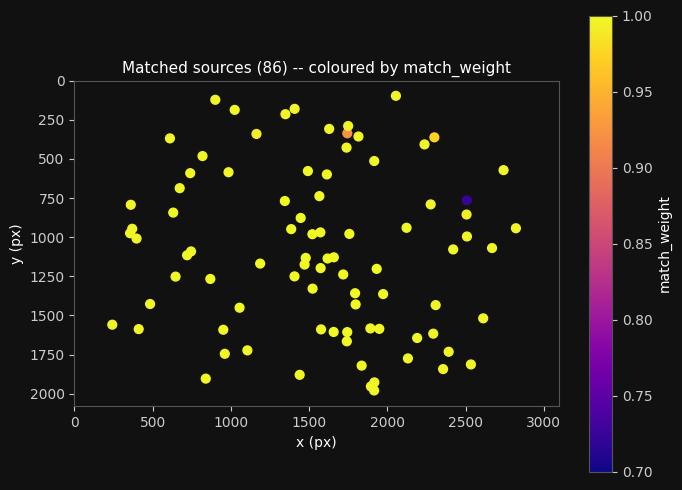

In [3]:
assert fid_result.corr_table is not None, (
    "corr_table is None -- re-run the fiducial solve with fetch_products=True "
    "or ensure the local .corr file was read successfully."
)

matched_xs      = np.asarray(fid_result.corr_table['field_x'],      dtype=float)
matched_ys      = np.asarray(fid_result.corr_table['field_y'],      dtype=float)
matched_weights = np.asarray(fid_result.corr_table['match_weight'], dtype=float)

# Sanity: must equal the matched_x/y stored in PlatesolveResult
assert np.allclose(matched_xs, fid_result.matched_x), \
    "corr field_x does not match fid_result.matched_x"
assert np.allclose(matched_ys, fid_result.matched_y), \
    "corr field_y does not match fid_result.matched_y"

n_matched = len(matched_xs)

print(f"Matched sources : {n_matched}")
print(f"Source file     : corr_table['field_x'/'field_y'] (xylist.corr from solve-field)")
print(f"Columns present : {fid_result.corr_table.colnames}")
print()
print(f"match_weight    : min={matched_weights.min():.4f}  "
      f"max={matched_weights.max():.4f}  mean={matched_weights.mean():.4f}")
print()
print("Pixel coordinate range:")
print(f"  x : [{matched_xs.min():.1f}, {matched_xs.max():.1f}]")
print(f"  y : [{matched_ys.min():.1f}, {matched_ys.max():.1f}]")

# Quick spatial plot of matched source positions
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(matched_xs, matched_ys, c=matched_weights,
                cmap='plasma', s=40, vmin=0.7, vmax=1.0)
plt.colorbar(sc, ax=ax, label='match_weight')
ax.set_xlim(0, nx); ax.set_ylim(0, ny)
ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
ax.set_title(f'Matched sources ({n_matched}) -- coloured by match_weight')
ax.set_aspect('equal')
ax.invert_yaxis()
fig.tight_layout()
plt.show()

## Cell 4 — Bootstrap configuration

`INDEX_RESTRICT` pins solve-field to index-4117 (confirmed used by the
fiducial solve).  `USE_FIELD_HINT` passes the known field center as
`--ra / --dec / --radius`, which makes each bootstrap solve faster and
more reliable when source count is lower.

In [5]:
# ---- bootstrap parameters (edit freely) ----
N_BOOT      = 250
BOOT_FRAC   = 0.80
BOOT_OUT    = OUT_DIR / 'boot_solves'
BOOT_OUT.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = OUT_DIR / 'bootstrap_results.csv'

# Restrict to confirmed index and pass known field center for speed
INDEX_RESTRICT   = str(INDEX_DIR / 'index-4117.fits')
USE_FIELD_HINT   = True
FIELD_HINT_RADIUS = 15.0   # degrees; generous to allow for WCS variation

RNG_SEED    = 42
MIN_BOOT_SRC = 40           # skip sample if too few sources survive
# ------------------------------------------

n_boot_src = int(n_matched * BOOT_FRAC)
rng = np.random.default_rng(RNG_SEED)
boot_indices = [
    rng.choice(n_matched, size=n_boot_src, replace=False)
    for _ in range(N_BOOT)
]

# Build extra_args list
_extra = []
if INDEX_RESTRICT:
    _ip = Path(INDEX_RESTRICT)
    if _ip.exists():
        _extra += ['--index', INDEX_RESTRICT]
        print(f"Index restrict   : {_ip.name}")
    else:
        print(f"WARNING: index file not found: {INDEX_RESTRICT}")
        print("  Falling back to scale-bounds search.")

if USE_FIELD_HINT:
    _extra += [
        '--ra',     f'{fid_metrics.ra_deg:.6f}',
        '--dec',    f'{fid_metrics.dec_deg:.6f}',
        '--radius', f'{FIELD_HINT_RADIUS:.1f}',
    ]
    print(f"Field hint       : RA={fid_metrics.ra_deg:.4f}  "
          f"Dec={fid_metrics.dec_deg:.4f}  r={FIELD_HINT_RADIUS} deg")

print(f"\nBootstrap config")
print(f"  Source pool      : {n_matched} matched sources (from fiducial corr_table)")
print(f"  N_BOOT           : {N_BOOT}")
print(f"  BOOT_FRAC        : {BOOT_FRAC:.0%}  ({n_boot_src} sources per sample)")
print(f"  MIN_BOOT_SRC     : {MIN_BOOT_SRC}")
print(f"  TWEAK_ORDER      : {TWEAK_ORDER}")
print(f"  SOLVE_TIMEOUT    : {SOLVE_TIMEOUT}s")
print(f"  Results CSV      : {RESULTS_CSV}")
print(f"  Est. total time  approx {N_BOOT * 15 // 60}-{N_BOOT * 25 // 60} min  "
      f"(field hint should speed up solves)")

Index restrict   : index-4117.fits
Field hint       : RA=113.4236  Dec=30.4264  r=15.0 deg

Bootstrap config
  Source pool      : 86 matched sources (from fiducial corr_table)
  N_BOOT           : 250
  BOOT_FRAC        : 80%  (68 sources per sample)
  MIN_BOOT_SRC     : 40
  TWEAK_ORDER      : 5
  SOLVE_TIMEOUT    : 120s
  Results CSV      : ../out/local_bootstrap_11/bootstrap_results.csv
  Est. total time  approx 62-104 min  (field hint should speed up solves)


## Cell 5 — Run matched-source bootstrap

Results are written to CSV after each solve.  Re-running this cell skips
iterations whose output directory already contains `xylist.wcs`.

In [6]:
_CSV_HEADER = ['boot_idx', 'n_src', 'north_angle_deg', 'ra_deg', 'dec_deg',
               'elapsed_s', 'status']

# Load already-completed rows
_done = {}
if RESULTS_CSV.exists():
    with open(RESULTS_CSV, newline='', encoding='utf-8') as _f:
        for _row in csv.DictReader(_f):
            if _row['status'] == 'ok':
                _done[int(_row['boot_idx'])] = _row
    print(f"Resuming: {len(_done)} successful results already saved.")
else:
    with open(RESULTS_CSV, 'w', newline='', encoding='utf-8') as _f:
        csv.writer(_f).writerow(_CSV_HEADER)

t_run_start = time.time()

for i, idx in enumerate(boot_indices):
    if i in _done:
        continue

    sub_xs = matched_xs[idx]
    sub_ys = matched_ys[idx]

    if len(sub_xs) < MIN_BOOT_SRC:
        _row = [i, len(sub_xs), '', '', '', '0', 'too_few_sources']
        with open(RESULTS_CSV, 'a', newline='', encoding='utf-8') as _f:
            csv.writer(_f).writerow(_row)
        print(f"{i:03d}/{N_BOOT}  n={len(sub_xs)}  SKIP (too few sources)")
        continue

    iter_dir   = BOOT_OUT / f'iter_{i:03d}'
    _wcs_file  = iter_dir / 'xylist.wcs'
    _wcs_exists = _wcs_file.exists()

    t0 = time.time()
    status = 'ok'
    m = None

    if _wcs_exists:
        # Re-read WCS from existing file without re-running solve-field
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                with fits.open(str(_wcs_file)) as _h:
                    _hdr = _h[0].header.copy()
            m = center_wcs_angle_metrics(_make_wcs(_hdr), image.shape,
                                         compute_east=False)
        except Exception as _e:
            status = f'wcs_read_error: {str(_e)[:80]}'
    else:
        try:
            _r = solve_plate(
                xs=sub_xs, ys=sub_ys,
                image_width=nx, image_height=ny,
                original_header=orig_header,
                backend='local',
                backend_config=BACKEND_CFG_STR,
                scale_units='arcsecperpix',
                scale_low=SCALE_LOW, scale_high=SCALE_HIGH,
                tweak_order=TWEAK_ORDER,
                output_dir=iter_dir,
                timeout=SOLVE_TIMEOUT,
                verbose=False,
                extra_args=_extra if _extra else None,
            )
            if _r is None:
                status = 'no_solution'
            else:
                m = center_wcs_angle_metrics(
                    _make_wcs(_r.header), image.shape, compute_east=False
                )
        except LocalSolveFieldError as _e:
            status = f'solver_error: {str(_e)[:80]}'
        except Exception as _e:
            status = f'error: {type(_e).__name__}: {str(_e)[:80]}'

    elapsed = time.time() - t0

    if m is not None:
        _dth = angle_diff_deg(m.north_angle_deg, fid_metrics.north_angle_deg)
        print(f"{i:03d}/{N_BOOT}  n={len(sub_xs)}  "
              f"theta={m.north_angle_deg:.4f} deg  "
              f"delta={_dth:+.4f} deg  [{elapsed:.0f}s]")
    else:
        print(f"{i:03d}/{N_BOOT}  n={len(sub_xs)}  "
              f"FAILED  [{status[:60]}  {elapsed:.0f}s]")

    _row = [
        i, len(sub_xs),
        m.north_angle_deg if m else '',
        m.ra_deg          if m else '',
        m.dec_deg         if m else '',
        f'{elapsed:.2f}',
        status,
    ]
    with open(RESULTS_CSV, 'a', newline='', encoding='utf-8') as _f:
        csv.writer(_f).writerow(_row)

print(f"\nBootstrap loop finished in {(time.time()-t_run_start)/60:.1f} min.")

000/250  n=68  theta=-106.7091 deg  delta=+0.2967 deg  [4s]
001/250  n=68  theta=-106.9526 deg  delta=+0.0531 deg  [4s]
002/250  n=68  theta=-106.9711 deg  delta=+0.0347 deg  [3s]
003/250  n=68  theta=-106.8806 deg  delta=+0.1252 deg  [2s]
004/250  n=68  theta=-106.9375 deg  delta=+0.0683 deg  [3s]
005/250  n=68  theta=-107.0663 deg  delta=-0.0606 deg  [4s]
006/250  n=68  theta=-107.1706 deg  delta=-0.1648 deg  [3s]
007/250  n=68  theta=-106.8809 deg  delta=+0.1248 deg  [3s]
008/250  n=68  theta=-107.0209 deg  delta=-0.0152 deg  [3s]
009/250  n=68  theta=-106.9726 deg  delta=+0.0332 deg  [3s]
010/250  n=68  theta=-107.0793 deg  delta=-0.0735 deg  [3s]
011/250  n=68  theta=-107.0716 deg  delta=-0.0658 deg  [3s]
012/250  n=68  theta=-106.9965 deg  delta=+0.0093 deg  [4s]
013/250  n=68  theta=-106.8809 deg  delta=+0.1248 deg  [2s]
014/250  n=68  theta=-106.9667 deg  delta=+0.0390 deg  [3s]
015/250  n=68  theta=-107.0524 deg  delta=-0.0467 deg  [2s]
016/250  n=68  theta=-106.8507 deg  delt

## Cell 6 — Bootstrap statistics

In [7]:
_rows = []
with open(RESULTS_CSV, newline='', encoding='utf-8') as _f:
    for _row in csv.DictReader(_f):
        if _row['status'] == 'ok' and _row['north_angle_deg']:
            _rows.append(_row)

n_ok     = len(_rows)
n_failed = N_BOOT - n_ok

if n_ok < 2:
    raise RuntimeError(
        f"Only {n_ok} successful bootstrap solves -- need at least 2.\n"
        "Check that solve-field is working and re-run Cell 5."
    )

boot_north = np.array([float(r['north_angle_deg']) for r in _rows])
boot_ra    = np.array([float(r['ra_deg'])          for r in _rows])
boot_dec   = np.array([float(r['dec_deg'])         for r in _rows])
boot_times = np.array([float(r['elapsed_s'])       for r in _rows])

fid_theta  = fid_metrics.north_angle_deg

boot_dtheta  = angle_diff_deg(boot_north, fid_theta)
boot_dra_as  = (angle_diff_deg(boot_ra, fid_metrics.ra_deg)
                * 3600 * np.cos(np.radians(fid_metrics.dec_deg)))
boot_ddec_as = (boot_dec - fid_metrics.dec_deg) * 3600
boot_sep_as  = np.hypot(boot_dra_as, boot_ddec_as)

boot_theta_std  = float(boot_dtheta.std())
boot_theta_med  = float(np.median(boot_dtheta))
boot_theta_mad  = float(np.median(np.abs(boot_dtheta - boot_theta_med)))
boot_sep_std    = float(boot_sep_as.std())
boot_ra_std     = float(boot_dra_as.std())
boot_dec_std    = float(boot_ddec_as.std())

print('=' * 64)
print('  MATCHED-SOURCE BOOTSTRAP STATISTICS')
print('=' * 64)
print(f'  Source pool      : {n_matched} matched sources')
print(f'  Sources per boot : {n_boot_src}  ({BOOT_FRAC:.0%})')
print(f'  Attempted        : {N_BOOT}')
print(f'  Solved (ok)      : {n_ok}')
print(f'  Failed           : {n_failed}')
print(f'  Avg solve time   : {boot_times.mean():.1f}s  '
      f'(min {boot_times.min():.0f}s  max {boot_times.max():.0f}s)')
print()
print(f'  Fiducial theta_north  : {fid_theta:.5f} deg')
print(f'  Bootstrap mean offset : {boot_dtheta.mean():+.5f} deg')
print(f'  Bootstrap median offs.: {boot_theta_med:+.5f} deg')
print(f'  Bootstrap sigma(theta): {boot_theta_std:.5f} deg   <-- X in error budget')
print(f'  Bootstrap MAD(theta)  : {boot_theta_mad:.5f} deg')
print(f'  theta range           : [{boot_north.min():.4f}, {boot_north.max():.4f}] deg')
print()
print(f'  sigma(sky sep)  : {boot_sep_std:.3f} arcsec')
print(f'  sigma(RA xcosD) : {boot_ra_std:.3f} arcsec')
print(f'  sigma(Dec)      : {boot_dec_std:.3f} arcsec')
print('=' * 64)

_summary = dict(
    image=str(FITS_PATH.name), notebook='11_local_wcs_matched_bootstrap',
    n_matched=int(n_matched), n_boot=N_BOOT, n_ok=n_ok, n_failed=n_failed,
    tweak_order=TWEAK_ORDER, boot_frac=BOOT_FRAC,
    index_restrict=INDEX_RESTRICT, use_field_hint=USE_FIELD_HINT,
    fid_north_angle_deg=fid_theta,
    fid_ra_deg=fid_metrics.ra_deg, fid_dec_deg=fid_metrics.dec_deg,
    boot_theta_std_deg=boot_theta_std,
    boot_theta_mad_deg=boot_theta_mad,
    boot_theta_mean_offset_deg=float(boot_dtheta.mean()),
    boot_sep_std_arcsec=boot_sep_std,
)
(OUT_DIR / 'bootstrap_summary.json').write_text(
    json.dumps(_summary, indent=2), encoding='utf-8'
)
print(f"Summary saved to {OUT_DIR / 'bootstrap_summary.json'}")

  MATCHED-SOURCE BOOTSTRAP STATISTICS
  Source pool      : 86 matched sources
  Sources per boot : 68  (80%)
  Attempted        : 250
  Solved (ok)      : 250
  Failed           : 0
  Avg solve time   : 3.0s  (min 2s  max 9s)

  Fiducial theta_north  : -107.00577 deg
  Bootstrap mean offset : +0.00915 deg
  Bootstrap median offs.: +0.00684 deg
  Bootstrap sigma(theta): 0.12760 deg   <-- X in error budget
  Bootstrap MAD(theta)  : 0.05149 deg
  theta range           : [-107.5443, -106.5595] deg

  sigma(sky sep)  : 222.628 arcsec
  sigma(RA xcosD) : 77.691 arcsec
  sigma(Dec)      : 247.777 arcsec
Summary saved to ../out/local_bootstrap_11/bootstrap_summary.json


## Cell 7 — Compare to full-list bootstrap (notebook 10)

If the notebook 10 bootstrap CSV exists, compare std and MAD to assess
whether source-selection noise was dominating the previous scatter.

**Interpretation guide:**
- Matched-source std << full-list std → previous scatter was dominated
  by bad detections or inconsistent spatial coverage, not the WCS fit.
- Matched-source std ≈ full-list std → the scatter is intrinsic to the
  order-5 WCS fit, not the source list.  The matched-source result is
  then the more conservative (and correct) estimate of X.

In [8]:
NB10_CSV = Path('..') / 'out' / 'local_bootstrap_10' / 'bootstrap_results.csv'

nb10_dtheta = nb10_std = nb10_mad = None
if NB10_CSV.exists():
    _nb10_rows = []
    with open(NB10_CSV, newline='', encoding='utf-8') as _f:
        for _row in csv.DictReader(_f):
            if _row['status'] == 'ok' and _row['north_angle_deg']:
                _nb10_rows.append(float(_row['north_angle_deg']))
    if _nb10_rows:
        _nb10_north = np.array(_nb10_rows)
        nb10_dtheta = angle_diff_deg(_nb10_north, fid_theta)
        nb10_std    = float(nb10_dtheta.std())
        nb10_mad    = float(np.median(np.abs(nb10_dtheta - np.median(nb10_dtheta))))
        n_nb10_ok   = len(_nb10_rows)

print('Bootstrap comparison')
print('-' * 56)
if nb10_std is not None:
    print(f"  Full-list  (nb10, N={n_nb10_ok:2d}):  "
          f"sigma={nb10_std:.5f} deg   MAD={nb10_mad:.5f} deg")
    print(f"  Matched    (nb11, N={n_ok:2d}):  "
          f"sigma={boot_theta_std:.5f} deg   MAD={boot_theta_mad:.5f} deg")
    _ratio = nb10_std / boot_theta_std if boot_theta_std > 0 else float('nan')
    print(f"  Ratio (full/matched)  :  {_ratio:.2f}x")
    print()
    if _ratio > 1.5:
        print("  -> Full-list scatter was significantly larger.")
        print("     Suggests source-selection noise dominated nb10.")
        print("     Matched-source sigma is the cleaner estimate of X.")
    elif _ratio < 0.75:
        print("  -> Matched-source scatter is larger than full-list.")
        print("     Unexpected -- check bootstrap samples and solve success.")
    else:
        print("  -> Scatter is comparable between both bootstraps.")
        print("     WCS fit uncertainty dominates, not source selection.")
        print("     Both estimates of X are consistent.")
else:
    print(f"  Full-list  (nb10)    :  CSV not found at {NB10_CSV}")
    print(f"  Matched    (nb11, N={n_ok:2d}):  "
          f"sigma={boot_theta_std:.5f} deg   MAD={boot_theta_mad:.5f} deg")
    print()
    print("  Run notebook 10 to generate the comparison data.")

Bootstrap comparison
--------------------------------------------------------
  Full-list  (nb10, N=50):  sigma=0.09228 deg   MAD=0.06702 deg
  Matched    (nb11, N=250):  sigma=0.12760 deg   MAD=0.05149 deg
  Ratio (full/matched)  :  0.72x

  -> Matched-source scatter is larger than full-list.
     Unexpected -- check bootstrap samples and solve success.


## Cell 8 — Histogram

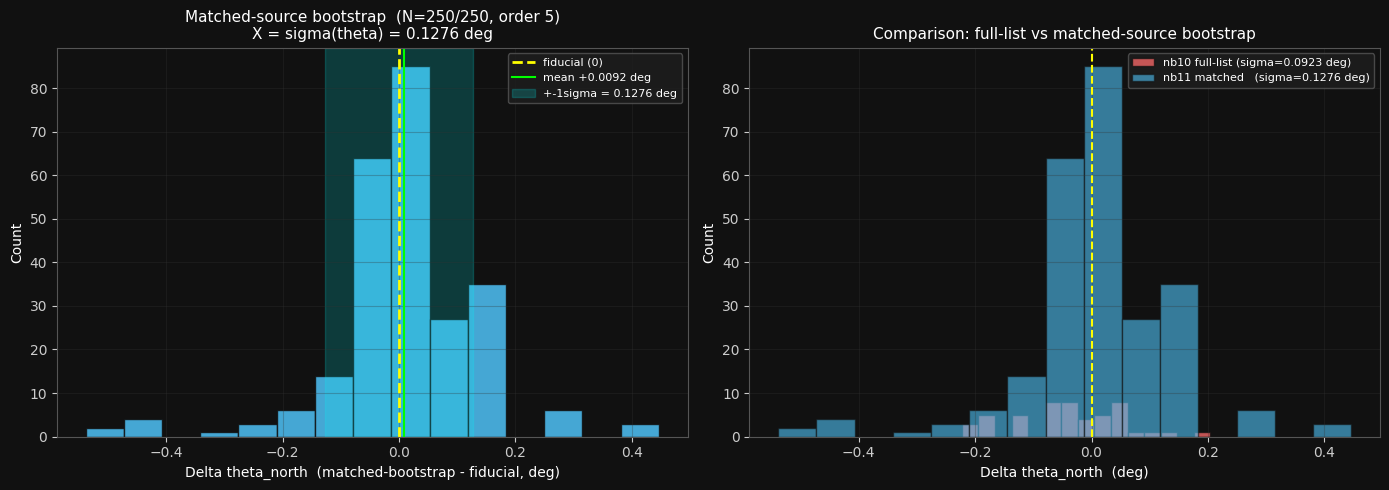

Saved ../out/local_bootstrap_11/bootstrap_histogram.png


In [9]:
ncols = 2 if nb10_dtheta is not None else 1
fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 5), squeeze=False)

# --- matched-source histogram ---
ax = axes[0, 0]
ax.hist(boot_dtheta, bins=min(15, n_ok),
        color='#4fc3f7', edgecolor='#111', alpha=0.85)
ax.axvline(0,                  color='yellow', lw=2,   ls='--', label='fiducial (0)')
ax.axvline(boot_dtheta.mean(), color='lime',   lw=1.5,
           label=f'mean {boot_dtheta.mean():+.4f} deg')
ax.axvspan(-boot_theta_std, boot_theta_std,
           alpha=0.18, color='cyan',
           label=f'+-1sigma = {boot_theta_std:.4f} deg')
ax.set_xlabel('Delta theta_north  (matched-bootstrap - fiducial, deg)')
ax.set_ylabel('Count')
ax.set_title(f'Matched-source bootstrap  (N={n_ok}/{N_BOOT}, order {TWEAK_ORDER})'
             f'\nX = sigma(theta) = {boot_theta_std:.4f} deg')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- full-list overlay (nb10) ---
if nb10_dtheta is not None:
    ax2 = axes[0, 1]
    ax2.hist(nb10_dtheta, bins=min(15, len(nb10_dtheta)),
             color='#ff6b6b', edgecolor='#111', alpha=0.75, label=f'nb10 full-list (sigma={nb10_std:.4f} deg)')
    ax2.hist(boot_dtheta, bins=min(15, n_ok),
             color='#4fc3f7', edgecolor='#111', alpha=0.60, label=f'nb11 matched   (sigma={boot_theta_std:.4f} deg)')
    ax2.axvline(0, color='yellow', lw=1.5, ls='--')
    ax2.set_xlabel('Delta theta_north  (deg)')
    ax2.set_ylabel('Count')
    ax2.set_title('Comparison: full-list vs matched-source bootstrap')
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)

fig.tight_layout()
_plot_path = OUT_DIR / 'bootstrap_histogram.png'
fig.savefig(_plot_path, bbox_inches='tight')
plt.show()
print(f"Saved {_plot_path}")

## Cell 9 — Fiducial WCS overlay

Visual sanity check with WCS grid, detected sources, and matched sources.
Confirmed WCS solution should look identical to notebook 10 Cell 8.

/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/lib/python3.11/site-packages/astropy/wcs/wcsapi/fitswcs.py:367: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/lib/python3.11/site-packages/astropy/wcs/wcsapi/fitswcs.py:367: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/lib/python3.11/site-packages/astropy/wcs/wcsapi/fitswcs.py:367: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/lib/python3.11/site-packages

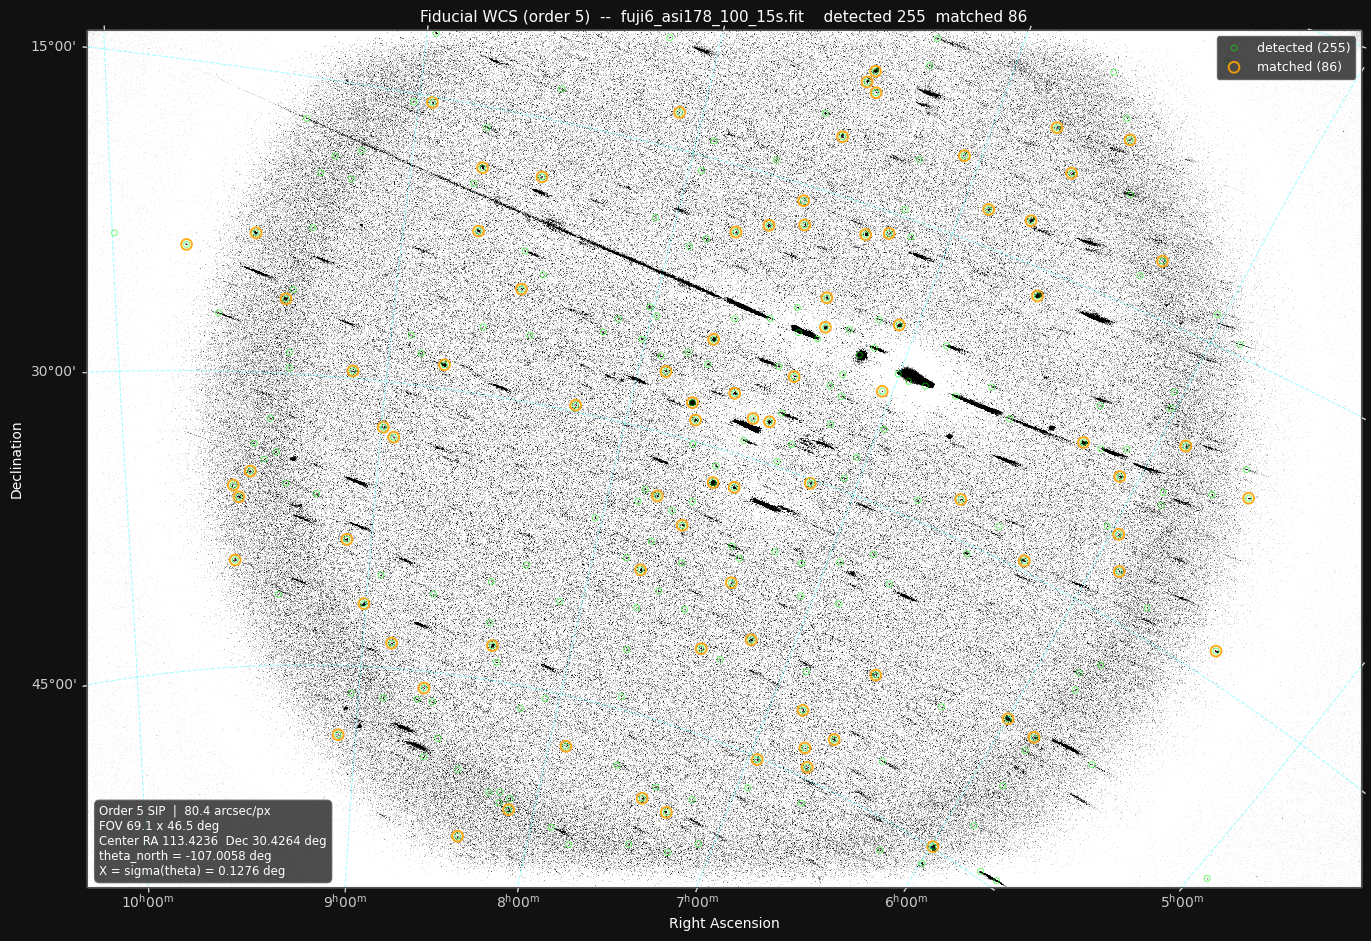

Saved ../out/local_bootstrap_11/fiducial_wcs_overlay.png


In [10]:
from astropy.visualization.wcsaxes import WCSAxes  # noqa: F401

fig = plt.figure(figsize=(14, 9.5))
ax  = fig.add_subplot(111, projection=fid_wcs)

ax.imshow(disp, origin='lower', cmap='gray_r',
          vmin=_dlo, vmax=_dhi, aspect='equal', interpolation='nearest')

ax.coords.grid(True, color='cyan', alpha=0.35, linestyle='--', linewidth=0.8)
ax.coords['ra'].set_major_formatter('hh:mm')
ax.coords['dec'].set_major_formatter('dd:mm')
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')

# All detected sources
ax.scatter(fid_result.detected_x, fid_result.detected_y,
           transform=ax.get_transform('pixel'),
           s=18, facecolors='none', edgecolors='lime', linewidths=0.8,
           alpha=0.5, label=f'detected ({len(fid_result.detected_x)})')

# Matched sources (larger, coloured by match_weight)
ax.scatter(matched_xs, matched_ys,
           transform=ax.get_transform('pixel'),
           s=60, facecolors='none', edgecolors='orange', linewidths=1.4,
           alpha=0.9, label=f'matched ({n_matched})')

ax.legend(fontsize=9, loc='upper right')

_boot_str = f'X = sigma(theta) = {boot_theta_std:.4f} deg'
_ann = (
    f'Order {TWEAK_ORDER} SIP  |  {_ps_arcsec:.1f} arcsec/px\n'
    f'FOV {_fov_x_deg:.1f} x {_fov_y_deg:.1f} deg\n'
    f'Center RA {fid_metrics.ra_deg:.4f}  Dec {fid_metrics.dec_deg:.4f} deg\n'
    f'theta_north = {fid_metrics.north_angle_deg:.4f} deg\n'
    f'{_boot_str}'
)
ax.text(0.01, 0.01, _ann, transform=ax.transAxes,
        fontsize=8.5, color='white', verticalalignment='bottom',
        bbox=dict(facecolor='#111', alpha=0.75,
                  edgecolor='#555', boxstyle='round,pad=0.4'))

ax.set_title(
    f'Fiducial WCS (order {TWEAK_ORDER})  --  {FITS_PATH.name}  '
    f'  detected {len(fid_result.detected_x)}  matched {n_matched}',
    fontsize=11,
)

fig.tight_layout()
_overlay_path = OUT_DIR / 'fiducial_wcs_overlay.png'
fig.savefig(_overlay_path, bbox_inches='tight')
plt.show()
print(f"Saved {_overlay_path}")